<h1 style="text-align: center;">
📊 Customer Retention, Churn, and LTV Analysis
</h1>

## 📑 Table of Contents

1. Introduction  
2. Executive Summary
3. Data Loading
4. Initial Exploration
5. Data Cleaning
6. Retention Cohort Analysis  
   - Cohort Size (Number of Customers)
   - Retention Rate by Cohort
7. Churn Cohort Analysis 
   - Global Churn Rate  
   - Churn Rate by Cohort  
8. Revenue Cohort Analysis  
9. LTV Cohort Analysis  
   - LTV by Cohort  
   - Cumulative LTV

## 📌 Introduction

This analysis explores customer retention, churn, and lifetime value using cohort analysis.

The goal is to understand how customer behavior changes over time, identify patterns in retention and inactivity, and evaluate how much value customers generate after their first purchase.

**Dataset:** [UCI Online Retail Dataset](https://archive.ics.uci.edu/dataset/352/online+retail) (541K+ transactions)

## 💡 Executive Summary

- Customer retention drops quickly after the first month, and churn remains high across most cohorts. This indicates that early engagement is the main challenge in the customer lifecycle.
- Most customer value (LTV) is generated in the first few months, with slower growth over time. This suggests that improving early retention and repeat purchase behavior is critical.
- Customer quality varies across cohorts, with earlier cohorts showing better retention, lower churn, and higher long-term value. This highlights the importance of optimizing acquisition channels and targeting higher-quality customers.

---

Overall, improving early retention and acquisition quality represents the biggest opportunity to increase long-term customer value.

## 📥 Data Loading

In [1]:
# Libraries
import pandas as pd

In [2]:
# Load sales dataset
df = pd.read_excel("Online Retail.xlsx")

In [3]:
# Display first rows of the dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 🔍 Initial Exploration

In [4]:
# Check dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
# Count missing values per column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 🧹 Data Cleaning

We clean the dataset to ensure that the analysis is based only on valid transactions.

We remove:
- Customers without an ID
- Returns (negative quantities)
- Invalid prices (zero or negative)

#### Customers without an ID

In [6]:
# Remove rows where CustomerID is missing (we cannot analyze these customers)
df = df.dropna(subset=["CustomerID"])

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


#### Returns

In [7]:
# Check for negative quantities (returns)
df[df["Quantity"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [8]:
# Remove returns (negative quantities)
df = df[df["Quantity"] > 0]

#### Invalid prices

In [9]:
# Check for zero or negative prices
df[df["UnitPrice"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom


In [10]:
# Remove invalid prices (they do not represent real revenue)
df = df[df["UnitPrice"] > 0]

In [11]:
# Check dataset size after cleaning
df.shape

(397884, 8)

## 📊 Retention Cohort Analysis

We analyze customer retention by grouping users based on their first purchase date.

This allows us to understand how customer behavior evolves over time and identify patterns of retention and churn.

#### Cohort Size (Number of Customers)

Shows the number of customers in each cohort based on their first purchase month.

This helps understand how many customers were acquired in each period and provides context for interpreting retention and revenue patterns.

In [12]:
# Create purchase month (cohort basis)
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12


In [13]:
# Get the first purchase month for each customer (cohort)
df["CohortMonth"] = df.groupby("CustomerID")["InvoiceMonth"].transform("min")
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth
34477,539395,22964,3 PIECE SPACEBOY COOKIE CUTTER SET,18,2010-12-17 11:52:00,2.10,12471.0,Germany,2010-12,2010-12
54551,540955,71053,WHITE METAL LANTERN,2,2011-01-12 13:27:00,3.75,14715.0,United Kingdom,2011-01,2011-01
350146,567613,15060B,FAIRY CAKE DESIGN UMBRELLA,4,2011-09-21 11:49:00,3.75,13908.0,United Kingdom,2011-09,2011-03
486304,577723,22417,PACK OF 60 SPACEBOY CAKE CASES,2,2011-11-21 12:36:00,0.55,16713.0,United Kingdom,2011-11,2010-12
349210,567482,22273,FELTCRAFT DOLL MOLLY,2,2011-09-20 13:42:00,2.95,16464.0,United Kingdom,2011-09,2011-07


In [14]:
# Calculate number of months between purchase and first purchase (cohort index)
df["CohortIndex"] = (df["InvoiceMonth"] - df["CohortMonth"]).apply(lambda x: x.n)
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex
486015,577696,22748,POPPY'S PLAYHOUSE KITCHEN,1,2011-11-21 11:57:00,2.10,16406.0,United Kingdom,2011-11,2011-11,0
263662,560025,20719,WOODLAND CHARLOTTE BAG,1,2011-07-14 13:00:00,0.85,18283.0,United Kingdom,2011-07,2011-01,6
422217,573070,23323,WHITE WICKER STAR,2,2011-10-27 13:59:00,2.10,13263.0,United Kingdom,2011-10,2011-01,9
285295,561900,22715,CARD WEDDING DAY,12,2011-07-31 15:31:00,0.42,16655.0,United Kingdom,2011-07,2011-01,6
117415,546386,22296,HEART IVORY TRELLIS LARGE,12,2011-03-11 13:31:00,1.65,14312.0,United Kingdom,2011-03,2011-01,2


In [15]:
# Group data by CohortMonth and CohortIndex and count unique customers
cohort_data = df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index()
cohort_data.sample(5)

,CohortMonth,CohortIndex,CustomerID
78,2011-08,2,42
11,2010-12,11,445
26,2011-02,1,71
13,2011-01,0,417
40,2011-03,4,101


In [16]:
# Create cohort table (matrix format)
cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")
cohort_pivot

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


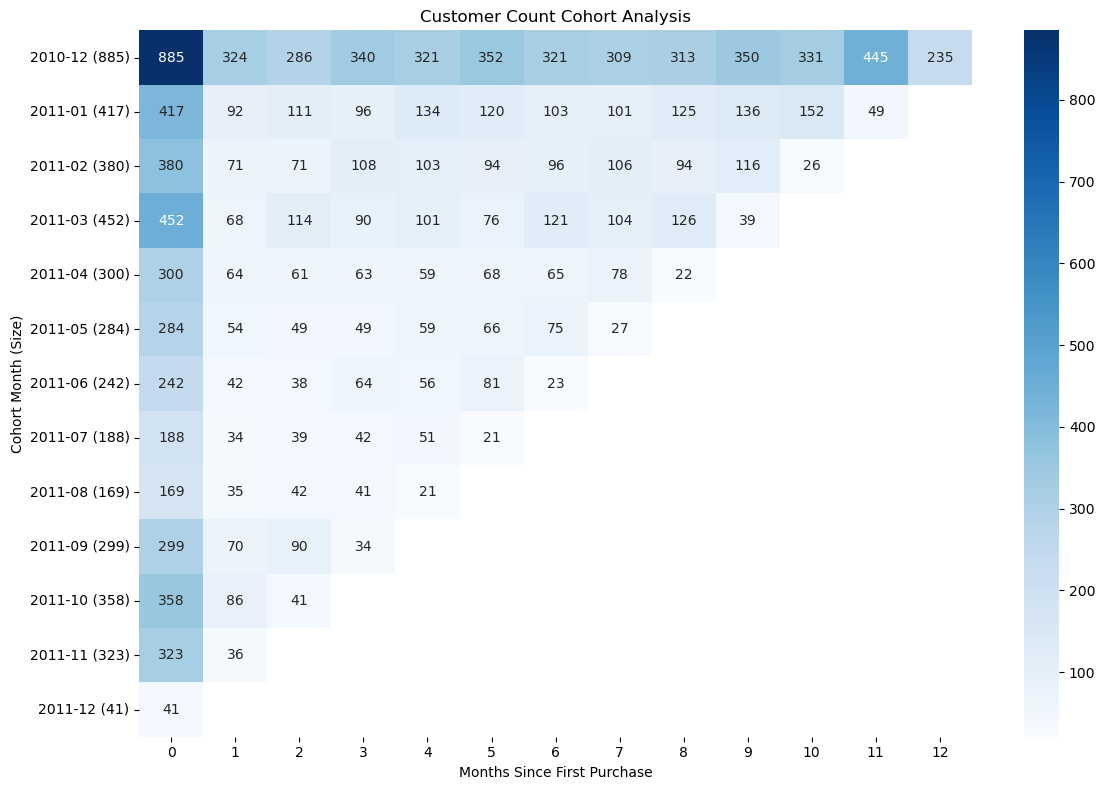

In [43]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Get cohort sizes
cohort_sizes = cohort_pivot.iloc[:, 0]

# Set figure size
plt.figure(figsize=(12, 8))

# Create heatmap
ax = sns.heatmap(cohort_pivot, annot=True, fmt=".0f", cmap="Blues")

# Modify y-axis labels
labels = [f"{date} ({int(size)})" for date, size in zip(cohort_sizes.index, cohort_sizes)]
ax.set_yticklabels(labels, rotation=0)

# Titles
plt.title("Customer Count Cohort Analysis")
plt.ylabel("Cohort Month (Size)")
plt.xlabel("Months Since First Purchase")

plt.tight_layout()
plt.show()

#### Retention Rate by Cohort

Measures the percentage of customers who return and make a purchase in subsequent months.

This helps evaluate how customer engagement evolves over time and identify patterns in retention across different cohorts.

In [18]:
# Divide each row by its first value (month 0) to get retention rate
cohort_retention = cohort_pivot.divide(cohort_pivot.iloc[:, 0], axis=0)
cohort_retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN
2011-05,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.180851,0.207447,0.223404,0.271277,0.111702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207101,0.248521,0.242604,0.124260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


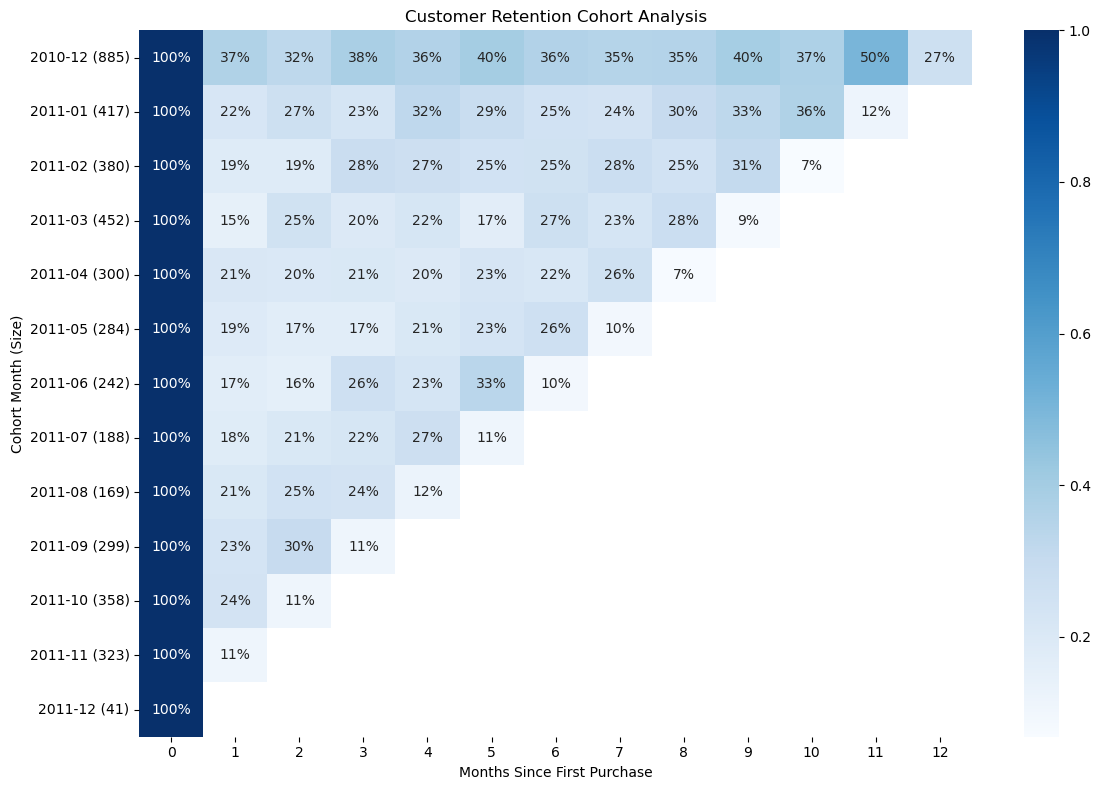

In [19]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Get cohort sizes
cohort_sizes = cohort_pivot.iloc[:, 0]

# Set figure size
plt.figure(figsize=(12, 8))

# Create heatmap
ax = sns.heatmap(cohort_retention, annot=True, fmt=".0%", cmap="Blues")

# Modify y-axis labels
labels = [f"{date} ({int(size)})" for date, size in zip(cohort_sizes.index, cohort_sizes)]
ax.set_yticklabels(labels, rotation=0)

# Titles
plt.title("Customer Retention Cohort Analysis")
plt.ylabel("Cohort Month (Size)")
plt.xlabel("Months Since First Purchase")

plt.tight_layout()
plt.show()

#### 📈 Key Insights

- Customer retention drops significantly after the first month, with most cohorts retaining only 15%–35% of users.
- Customers who remain active after the first few months tend to show more stable behavior over time, forming a core group of repeat customers.
- Some cohorts perform better than others, suggesting potential differences in acquisition channels, promotions, or seasonality.
- Early cohorts show slightly stronger long-term retention compared to more recent ones.

## 📉 Churn Cohort Analysis

Churn is defined as customer inactivity over time.

A customer is considered churned if they have not made a purchase within the last 3 months relative to the most recent date in the dataset.

This is a point-in-time (snapshot) definition of churn, meaning it reflects current inactivity rather than permanent customer loss.

#### Global Churn Rate

Measures the percentage of customers who are currently inactive based on the defined churn window (3 months). It provides a snapshot of overall customer retention health at the most recent point in time.

In [20]:
# Get the last purchase date for each customer
last_purchase = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
last_purchase.columns = ["CustomerID", "LastPurchaseDate"]

last_purchase.head()

,CustomerID,LastPurchaseDate
0,12346.0,2011-01-18 10:01:00
1,12347.0,2011-12-07 15:52:00
2,12348.0,2011-09-25 13:13:00
3,12349.0,2011-11-21 09:51:00
4,12350.0,2011-02-02 16:01:00


In [21]:
# Get the most recent date in the dataset
max_date = df["InvoiceDate"].max()

max_date

Timestamp('2011-12-09 12:50:00')

In [22]:
# Calculate months since last purchase
last_purchase["MonthsSinceLastPurchase"] = (
    (max_date - last_purchase["LastPurchaseDate"]) / pd.Timedelta(days=30)
).astype(int)

last_purchase.head()

,CustomerID,LastPurchaseDate,MonthsSinceLastPurchase
0,12346.0,2011-01-18 10:01:00,10
1,12347.0,2011-12-07 15:52:00,0
2,12348.0,2011-09-25 13:13:00,2
3,12349.0,2011-11-21 09:51:00,0
4,12350.0,2011-02-02 16:01:00,10


In [23]:
# Define churn (customers inactive for 3 or more months)
last_purchase["Churn"] = last_purchase["MonthsSinceLastPurchase"] >= 3

last_purchase.head()

,CustomerID,LastPurchaseDate,MonthsSinceLastPurchase,Churn
0,12346.0,2011-01-18 10:01:00,10,True
1,12347.0,2011-12-07 15:52:00,0,False
2,12348.0,2011-09-25 13:13:00,2,False
3,12349.0,2011-11-21 09:51:00,0,False
4,12350.0,2011-02-02 16:01:00,10,True


In [24]:
# Calculate churn rate
churn_rate = last_purchase["Churn"].mean()

# Print churn rate as percentage
print(f"Churn rate: {churn_rate:.2%}")

Churn rate: 33.40%


#### 📈 Key Insights

A global churn rate of 33.40% means that approximately one third of customers are currently inactive, suggesting an opportunity to improve customer retention.

#### Churn Rate by Cohort

Measures the percentage of churned customers for each cohort (grouped by first purchase month). It helps compare how customer retention varies across different acquisition periods and identify trends in customer quality over time.

In [25]:
# Add CohortMonth to the last_purchase table
cohort_map = df.groupby("CustomerID")["CohortMonth"].first().reset_index()

last_purchase = last_purchase.merge(cohort_map, on="CustomerID", how="left")

last_purchase.head()

,CustomerID,LastPurchaseDate,MonthsSinceLastPurchase,Churn,CohortMonth
0,12346.0,2011-01-18 10:01:00,10,True,2011-01
1,12347.0,2011-12-07 15:52:00,0,False,2010-12
2,12348.0,2011-09-25 13:13:00,2,False,2010-12
3,12349.0,2011-11-21 09:51:00,0,False,2011-11
4,12350.0,2011-02-02 16:01:00,10,True,2011-02


In [26]:
# Calculate churn rate by cohort
churn_by_cohort = last_purchase.groupby("CohortMonth")["Churn"].mean()

# Convert to percentage
churn_by_cohort_pct = churn_by_cohort * 100

# Display as percentage
print(churn_by_cohort_pct.round(2).astype(str) + "%")

CohortMonth
2010-12    30.85%
2011-01    38.61%
2011-02    46.32%
2011-03    47.79%
2011-04    54.33%
2011-05    48.24%
2011-06    46.69%
2011-07    53.72%
2011-08    50.89%
2011-09     7.69%
2011-10      0.0%
2011-11      0.0%
2011-12      0.0%
Freq: M, Name: Churn, dtype: object


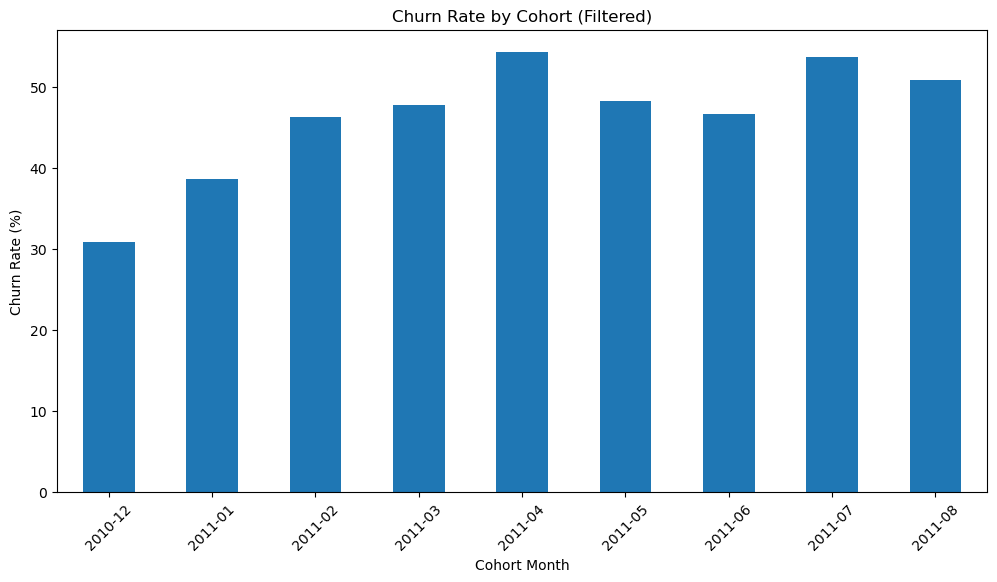

In [27]:
# Filter cohorts with enough observation time
churn_filtered = churn_by_cohort_pct[churn_by_cohort_pct.index <= "2011-08"]

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

churn_filtered.plot(kind="bar")

plt.title("Churn Rate by Cohort (Filtered)")
plt.xlabel("Cohort Month")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)

plt.show()

I excluded recent cohorts to avoid bias, since there hasn’t been enough time to properly measure churn.

#### 📈 Key Insights

- Churn is higher in more recent cohorts, suggesting a decline in customer quality or retention effectiveness. This indicates a need to review acquisition channels and onboarding experience.
- Several cohorts show churn rates above 45%, meaning that nearly half of customers become inactive. This highlights the importance of improving early retention strategies.
- Earlier cohorts have lower churn rates, indicating stronger customer engagement. Analyzing what worked in these periods can help replicate better retention outcomes.

## 💰 Revenue Cohort Analysis

Measures how much revenue each cohort generates over time.

It helps understand how customer value evolves after acquisition and identify differences in total revenue across cohorts.

It is important to note that this analysis reflects total revenue, which may be influenced by cohort size rather than individual customer value.

In [28]:
# Calculate revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12,2010-12,0,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,2010-12,0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12,2010-12,0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,2010-12,0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,2010-12,0,20.34


In [29]:
# Group revenue by cohort and cohort index
revenue_data = df.groupby(["CohortMonth", "CohortIndex"])["Revenue"].sum().reset_index()

revenue_data.head()

,CohortMonth,CohortIndex,Revenue
0,2010-12,0,572713.89
1,2010-12,1,276237.69
2,2010-12,2,233845.37
3,2010-12,3,303119.39
4,2010-12,4,204407.66


In [30]:
# Create revenue cohort table (matrix format)
revenue_pivot = revenue_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Revenue"
)

revenue_pivot

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,572713.890,276237.69,233845.37,303119.39,204407.66,336627.50,314162.61,310783.92,331749.220,472813.64,456080.61,513803.59,185803.13
2011-01,293207.350,55149.91,63268.17,71587.40,81114.09,84583.78,70107.40,72689.71,72023.651,111803.90,123882.10,26464.82,NaN
2011-02,158142.070,29043.24,41134.38,48238.86,40147.91,34223.23,49706.63,62450.83,55380.060,64809.45,10600.22,NaN,NaN
2011-03,200069.960,30059.43,59057.51,42816.61,51657.33,40020.81,64919.49,71023.95,71265.830,12868.02,NaN,NaN,NaN
2011-04,122011.491,29452.82,25077.07,24311.47,26314.19,30206.30,28668.98,34228.61,6350.100,NaN,NaN,NaN,NaN
2011-05,124103.780,18682.76,20193.76,19162.17,27861.87,32976.60,33312.91,179251.53,NaN,NaN,NaN,NaN,NaN
2011-06,135742.950,14805.15,14155.40,30961.59,26754.54,42808.25,8227.35,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,74008.751,11789.67,15534.18,17551.47,19512.11,6072.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,79756.100,20962.93,35503.90,44541.76,15284.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


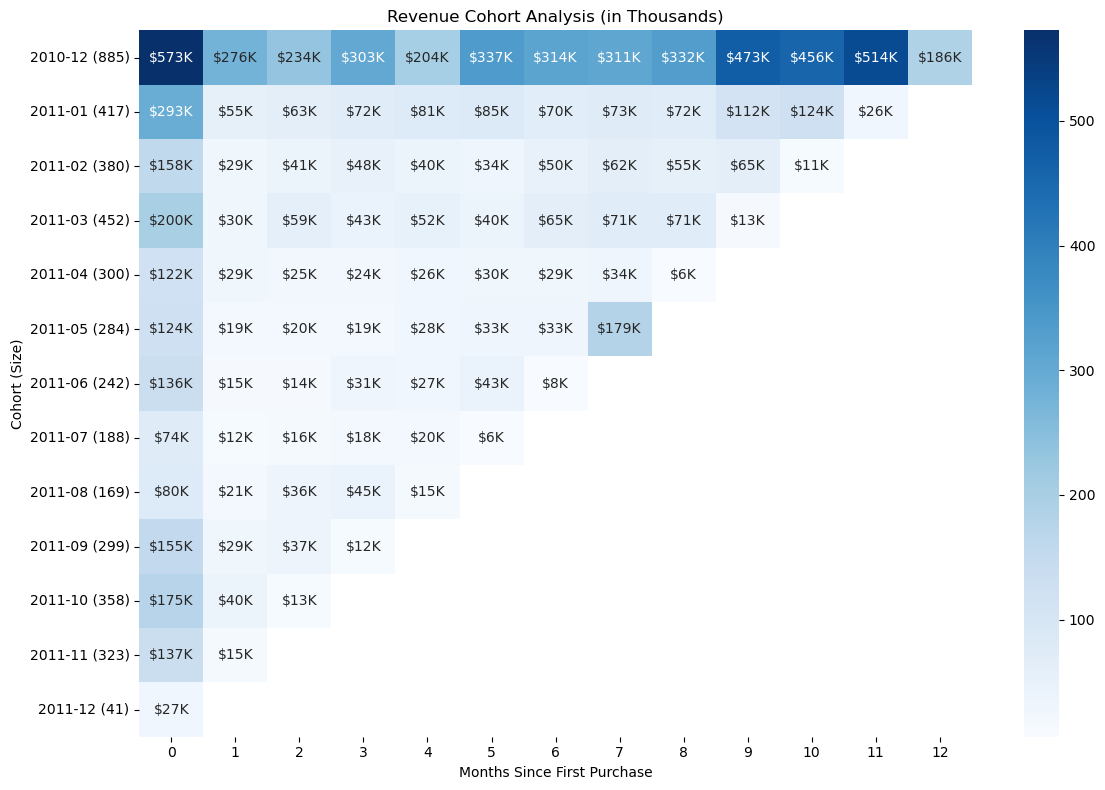

In [31]:
# Plot revenue cohort heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

ax = sns.heatmap(
    revenue_pivot / 1000,
    cmap="Blues",
    annot=True,
    fmt=".0f"
)

for t in plt.gca().texts:
    t.set_text(f"${t.get_text()}K")

# Modify y-axis labels
labels = [f"{date} ({int(size)})" for date, size in zip(revenue_pivot.index, cohort_sizes)]
ax.set_yticklabels(labels, rotation=0)
    
plt.title("Revenue Cohort Analysis (in Thousands)")
plt.ylabel("Cohort (Size)")
plt.xlabel("Months Since First Purchase")

plt.tight_layout()
plt.show()

#### 📈 Key Insights

- Revenue is declining in more recent cohorts, suggesting a drop in customer quality or acquisition effectiveness. This indicates a need to review acquisition channels and targeting strategies.
- Early cohorts generate significantly more revenue, likely driven by both better retention and larger cohort size. Understanding what worked in these periods can help replicate successful strategies.
- Revenue alone can be misleading, as it is influenced by cohort size. To make better decisions, it should be analyzed together with LTV to evaluate true customer value.

## 🏆 LTV Cohort Analysis

Measures the average revenue generated per customer within each cohort over time.

It helps evaluate customer quality by showing how much value each customer contributes after acquisition.

Unlike total revenue, this metric normalizes for cohort size, allowing for a more accurate comparison of customer value across cohorts.

#### LTV by Cohort
Shows the average revenue per customer in each period since acquisition, helping identify how customer value evolves over time.

In [33]:
# Calculate LTV by dividing revenue by cohort size
ltv_pivot = revenue_pivot.divide(cohort_sizes, axis=0)

ltv_pivot

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,647.134339,312.132983,264.232056,342.507785,230.969107,380.370056,354.986000,351.168271,374.857876,534.252701,515.345322,580.569028,209.94704
2011-01,703.135132,132.253981,151.722230,171.672422,194.518201,202.838801,168.123261,174.315851,172.718588,268.114868,297.079376,63.464796,NaN
2011-02,416.163342,76.429579,108.248368,126.944368,105.652395,90.061132,130.806921,164.344289,145.737000,170.551184,27.895316,NaN,NaN
2011-03,442.632655,66.503164,130.658208,94.727013,114.286128,88.541615,143.627190,157.132633,157.667765,28.469071,NaN,NaN,NaN
2011-04,406.704970,98.176067,83.590233,81.038233,87.713967,100.687667,95.563267,114.095367,21.167000,NaN,NaN,NaN,NaN
2011-05,436.985141,65.784366,71.104789,67.472430,98.105176,116.114789,117.298979,631.167359,NaN,NaN,NaN,NaN,NaN
2011-06,560.921281,61.178306,58.493388,127.940455,110.555950,176.893595,33.997314,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,393.663569,62.711011,82.628617,93.358883,103.787819,32.298723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,471.929586,124.041006,210.082249,263.560710,90.440000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


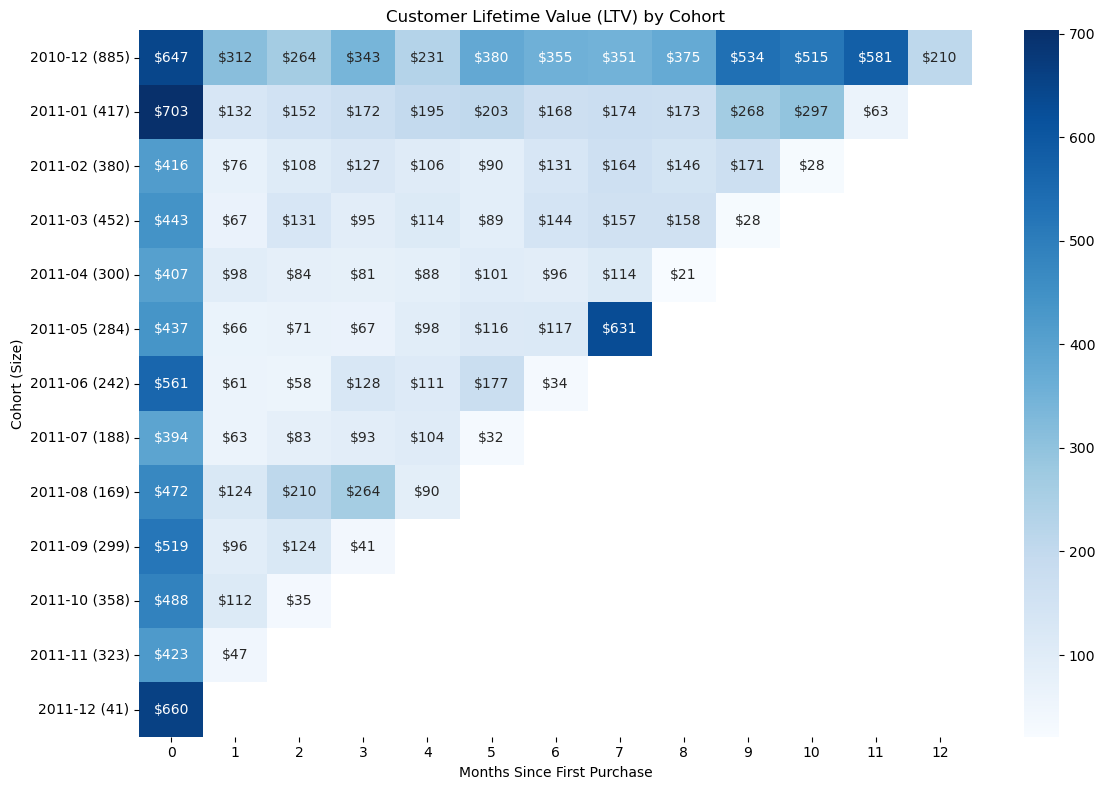

In [34]:
# Plot LTV cohort heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

ax = sns.heatmap(
    ltv_pivot,
    cmap="Blues",
    annot=True,
    fmt=".0f"
)

# Format values as dollars and improve contrast
for text in ax.texts:
    value = float(text.get_text())
    text.set_text(f"${value:,.0f}")

# Modify y-axis labels
labels = [f"{date} ({int(size)})" for date, size in zip(cohort_sizes.index, cohort_sizes)]
ax.set_yticklabels(labels, rotation=0)
    
plt.title("Customer Lifetime Value (LTV) by Cohort")
plt.ylabel("Cohort (Size)")
plt.xlabel("Months Since First Purchase")

plt.tight_layout()
plt.show()

### 📈 Key Insights

- LTV drops sharply after the first month across most cohorts, suggesting that most value is generated early. This highlights the need to improve early retention and repeat purchase strategies.
- Some cohorts show stronger LTV growth over time (e.g. 2010-12, 2011-01), indicating higher customer quality. Analyzing acquisition sources from these cohorts can help replicate better-performing customers.
- A few cohorts show sudden spikes in LTV (e.g. 2011-05), which may be driven by specific campaigns or promotions. Identifying these drivers can help scale high-value behaviors.

#### Cumulative LTV
Represents the total value generated per customer over time, making it easier to compare long-term customer value across cohorts.

In [35]:
# Calculate cumulative LTV by cohort
ltv_cumulative = ltv_pivot.cumsum(axis=1)

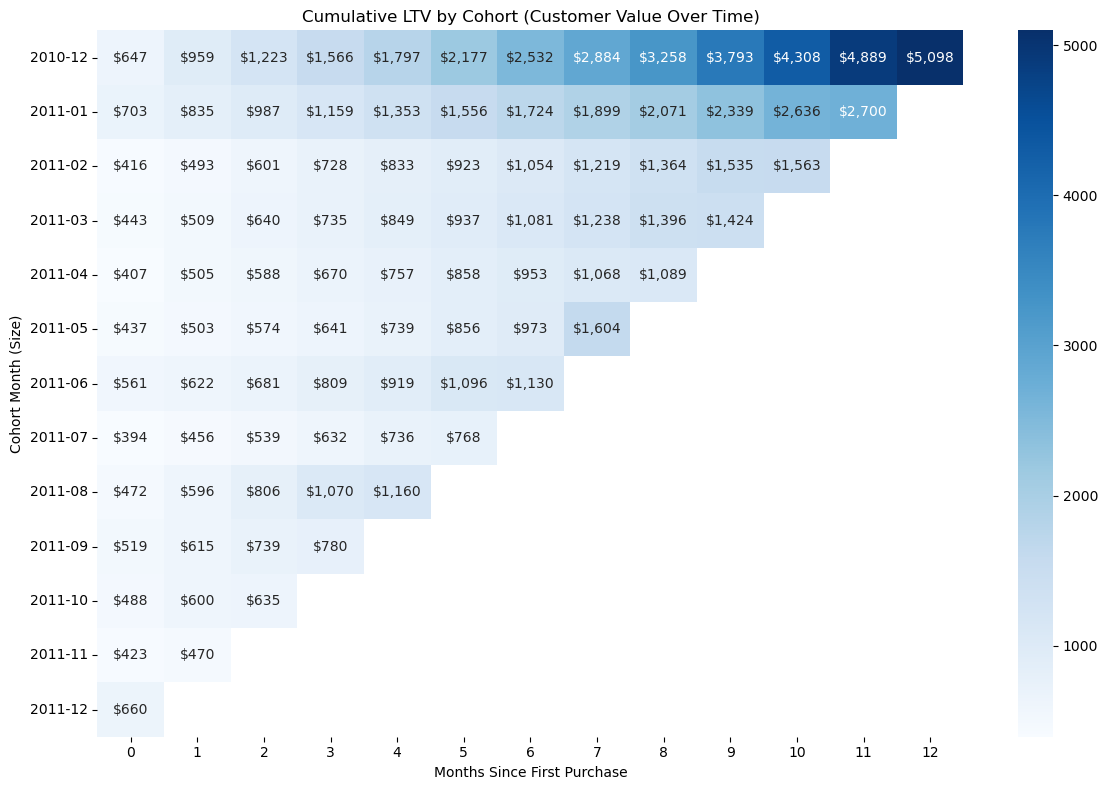

In [36]:
# Plot cumulative LTV cohort heatmap
plt.figure(figsize=(12, 8))

ax = sns.heatmap(
    ltv_cumulative,
    cmap="Blues",
    annot=True,
    fmt=".0f"
)

# Format values as dollars
for text in ax.texts:
    value = float(text.get_text())
    text.set_text(f"${value:,.0f}")

plt.title("Cumulative LTV by Cohort (Customer Value Over Time)")
plt.ylabel("Cohort Month (Size)")
plt.xlabel("Months Since First Purchase")

plt.tight_layout()
plt.show()

### 📈 Key Insights

- Cumulative LTV grows steadily over time, but the growth rate slows after the first few months. This suggests that most customer value is captured early, reinforcing the need to focus on early retention and upselling.
- Some cohorts reach significantly higher long-term value (e.g. 2010-12), indicating stronger customer quality. This highlights the importance of identifying and scaling the acquisition channels behind these cohorts.
- Later cohorts show lower cumulative LTV, suggesting a decline in long-term customer value. This points to potential issues in acquisition strategy or customer experience that should be addressed.